# Imports & paths

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import joblib
import json


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from lightgbm import LGBMClassifier
import shap

from pathlib import Path
DATA_INTERIM = Path("../data/interim")
DATA_PROCESSED = Path("../data/processed")

c:\Users\hoatr\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load clean data

In [2]:
df_customers = pd.read_parquet(DATA_INTERIM / "customers_clean.parquet")
df_txn = pd.read_parquet(DATA_INTERIM / "transactions_clean.parquet")

# Create churn labels

In [3]:
snapshot_date = pd.Timestamp("2025-09-30")

- Ta chọn **snapshot_date** là vì sẽ có đủ thời gian quan sát và label user 90 ngày

In [4]:
def label_churn(df_txn, snapshot_date, pred_window):
    future = df_txn[
        (df_txn["transaction_date"] > snapshot_date) &
        (df_txn["transaction_date"] <= snapshot_date + timedelta(days=pred_window))
    ]
    active_customers = future["customer_id"].unique()
    
    labels = (
        df_txn[df_txn["transaction_date"] <= snapshot_date]
        [["customer_id"]]
        .drop_duplicates()
    )
    labels["churn_90d"] = ~labels["customer_id"].isin(active_customers)
    return labels


churn_label = label_churn(df_txn, snapshot_date, 90)

In [5]:
customers_churn = df_customers.merge(
    churn_label,
    on="customer_id",
    how="inner"
)

customers_churn.head()

,customer_id,signup_date,true_lifetime_days,churn_90d
0,C00000,2025-08-22,204,False
1,C00001,2025-03-07,365,False
2,C00002,2025-08-18,48,True
3,C00004,2025-05-28,113,True
4,C00006,2025-08-22,117,False


In [6]:
customers_churn["churn_90d"].value_counts()

True     1154
False    1086
Name: churn_90d, dtype: int64

## Evaluation 

In [7]:
customers_churn.groupby("churn_90d")["true_lifetime_days"].mean()

churn_90d
False    225.595764
True     101.319757
Name: true_lifetime_days, dtype: float64

Ta thấy churn = 1 có lifetime thấp hơn → label đã hợp lý

In [8]:
customers_churn.to_parquet(
    DATA_PROCESSED / "churn_prediction_labels.parquet",
    index=False
)

# Feature engineering

In [9]:
churn = pd.read_parquet(DATA_PROCESSED / "churn_prediction_labels.parquet")

In [10]:
def build_window_features(df, window_days):

    hist = df[df["transaction_date"] <= snapshot_date].copy()


    agg = hist.groupby("customer_id").agg(
        # Recency
        recency=(
            "transaction_date",
            lambda x: (snapshot_date - x.max()).days
        ),

        # Frequency windows
        freq_30d=(
            "transaction_date",
            lambda x: (x >= snapshot_date - timedelta(days=30)).sum()
        ),
        freq_60d=(
            "transaction_date",
            lambda x: (x >= snapshot_date - timedelta(days=60)).sum()
        ),
        freq_90d=(
            "transaction_date",
            lambda x: (x >= snapshot_date - timedelta(days=90)).sum()
        ),

        # Monetary windows
        monetary_30d=(
            "amount",
            lambda x: x[
                hist.loc[x.index, "transaction_date"] >= snapshot_date - timedelta(days=30)
            ].sum()
        ),
        monetary_60d=(
            "amount",
            lambda x: x[
                hist.loc[x.index, "transaction_date"] >= snapshot_date - timedelta(days=60)
            ].sum()
        ),
        monetary_90d=(
            "amount",
            lambda x: x[
                hist.loc[x.index, "transaction_date"] >= snapshot_date - timedelta(days=90)
            ].sum()
        ),
    )

    # 3. Decay / ratio features
    agg["freq_ratio_30_90"] = agg["freq_30d"] / (agg["freq_90d"] + 1e-6)
    agg["freq_ratio_60_90"] = agg["freq_60d"] / (agg["freq_90d"] + 1e-6)

    return agg.reset_index()


features = build_window_features(df_txn, snapshot_date)
df = features.merge(churn, on="customer_id")

df.head()

,customer_id,recency,freq_30d,freq_60d,freq_90d,monetary_30d,monetary_60d,monetary_90d,freq_ratio_30_90,freq_ratio_60_90,signup_date,true_lifetime_days,churn_90d
0,C00000,18,2,2,2,246.65,246.65,246.65,1.000000,1.000000,2025-08-22,204,False
1,C00001,19,1,2,5,35.45,97.70,394.12,0.200000,0.400000,2025-03-07,365,False
2,C00002,4,6,11,11,372.60,910.64,910.64,0.545454,1.000000,2025-08-18,48,True
3,C00004,16,2,7,13,152.14,597.95,1355.44,0.153846,0.538461,2025-05-28,113,True
4,C00006,26,1,1,1,20.20,20.20,20.20,0.999999,0.999999,2025-08-22,117,False


In [11]:
df["churn_90d"].value_counts()

True     1154
False    1086
Name: churn_90d, dtype: int64

In [12]:
feature_cols = [
    "recency",    # RFM
    "freq_30d", "freq_60d", "freq_90d",     # rolling frequency
    "monetary_30d", "monetary_60d", "monetary_90d",     # rolling monetary
    "freq_ratio_30_90", "freq_ratio_60_90"     # decay ratios
]

target = "churn_90d"

# Temporal train / val / test split

In [13]:
X = df[feature_cols]
y = df[target].astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)

print(X_test.shape, y_test.shape)

(1568, 9) (1568,)
(672, 9) (672,)


# LightGBM Baseline

In [14]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.05, max_depth=5, n_estimators=300,
               random_state=42)

## Evaluation 

In [15]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC Score: ", auc)

AUC Score:  0.9279318415546651


In [16]:
def find_optimal_threshold(y_true, y_probs):

    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    scores = tpr - fpr
    optimal_idx_ = np.argmax(scores)
    optimal_threshold = thresholds[optimal_idx_]
    
    print(f"Optimal Threshold: {optimal_threshold:.4f}")

    return optimal_threshold, fpr, tpr, thresholds

In [17]:
optimal_thresh, fpr_val, tpr_val, all_thresholds = find_optimal_threshold(y_test, y_pred_proba)

y_pred_optimal = (y_pred_proba >= optimal_thresh).astype(int)
y_pred_default = (y_pred_proba >= 0.5).astype(int)

print(f"\nModel performance with default threshold (0.5):")
print(f"AUC: {roc_auc_score(y_test, y_pred_default):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall Score: {recall_score(y_test, y_pred_default):.4f}")

print(f"\nModel performance with optimal threshold of {optimal_thresh:.4f}:")
print(f"AUC: {roc_auc_score(y_test, y_pred_optimal):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Recall Score: {recall_score(y_test, y_pred_optimal):.4f}")

Optimal Threshold: 0.7785

Model performance with default threshold (0.5):
AUC: 0.8629
Precision Score: 0.8649
Recall Score: 0.8699

Model performance with optimal threshold of 0.7785:
AUC: 0.8802
Precision Score: 0.9490
Recall Score: 0.8064


In [18]:
target_names = ['non-churn', 'churn']
print(classification_report(y_test, y_pred_optimal, target_names=target_names))

              precision    recall  f1-score   support

   non-churn       0.82      0.95      0.88       326
       churn       0.95      0.81      0.87       346

    accuracy                           0.88       672
   macro avg       0.89      0.88      0.88       672
weighted avg       0.89      0.88      0.88       672



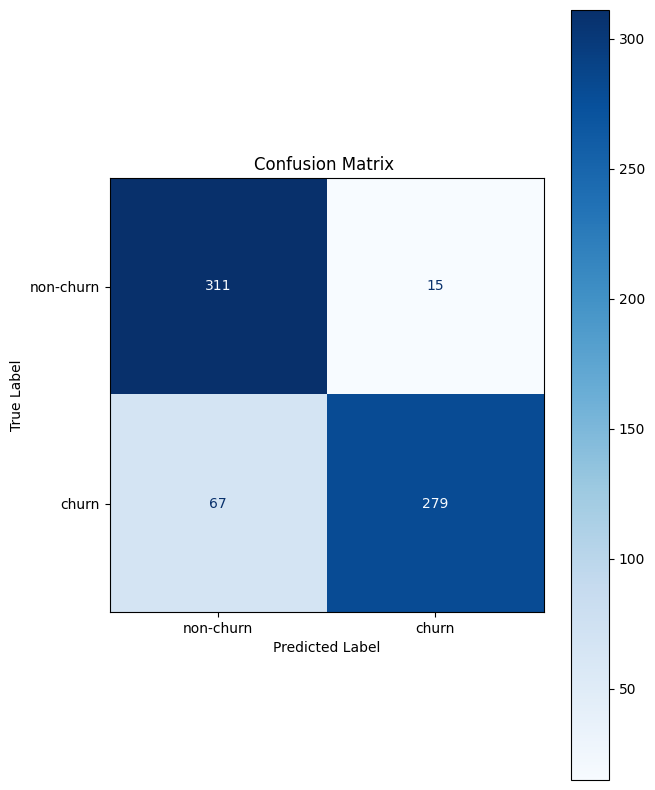

In [19]:
cm = confusion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(7, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues) 

ax.set_title('Confusion Matrix ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Show the plot
plt.show()

# Feature Importance

In [20]:
imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

imp

,feature,importance
0,recency,1231
6,monetary_90d,795
4,monetary_30d,646
5,monetary_60d,644
7,freq_ratio_30_90,386
8,freq_ratio_60_90,351
3,freq_90d,292
2,freq_60d,225
1,freq_30d,132


c:\Users\hoatr\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


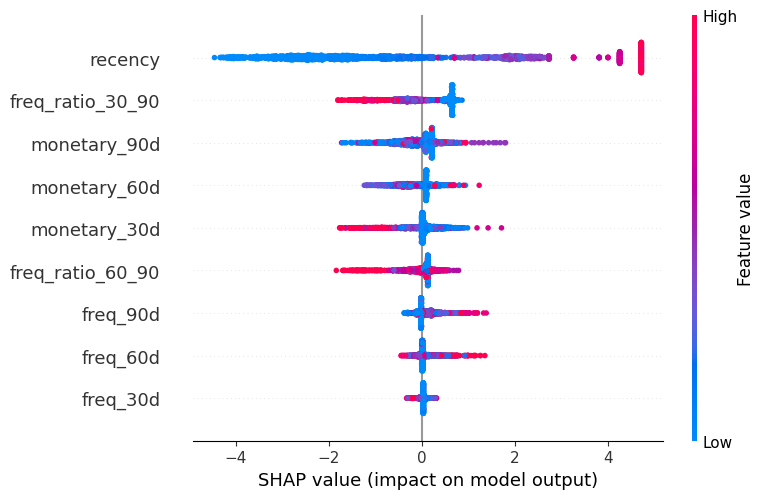

In [21]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

# Log

In [22]:
ART_MODELS = Path("../artifacts/models")
ART_REPORTS = Path("../artifacts/reports")
ART_SCORES = Path("../artifacts/scores")

In [26]:
# joblib.dump(model, ART_MODELS / "churn_lgbm.pkl")

booster = model.booster_
booster.save_model(ART_MODELS / "churn_lgbm.pkl")

In [24]:
metrics = {
    "auc": float(auc),
    "threshold": float(optimal_thresh),
    "method": "Youden's J statistic",
    "precision": float(precision_score(y_test, y_pred_optimal, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred_optimal, zero_division=0)),
}

with open(ART_REPORTS / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

In [25]:
scores_test = pd.DataFrame({
    "customer_id": X_test.index if hasattr(X_test, "index") else np.arange(len(X_test)),
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "y_pred": y_pred_optimal
})

scores_test.to_parquet(ART_SCORES / "scores_test.parquet", index=False)